# Reto 04 — Deep Q-Learning aplicado a eficiencias financieras

**Curso:** Aprendizaje por Refuerzo — Universidad EIA  
**Integrante:** Sebastián Roldán  
**Correo:** sebastian.roldan93@eia.edu.co  
**Fecha:** 2026-08-20

## Objetivo

Construir un agente de **Deep Q-Learning (DQN)** que aprenda a priorizar oportunidades de eficiencia financiera y a asignarlas a un perfil del equipo, teniendo en cuenta:

- la eficiencia potencial,
- el esfuerzo requerido,
- la cantidad de personas impactadas,
- el tipo de intervención más apropiado,
- la especialización y capacidad disponible del equipo.

El escenario está inspirado en mi trabajo en analítica financiera, pero todos los datos son **simulados** y los perfiles fueron generalizados para no utilizar información real de la empresa.

## 1. Descripción del ambiente

Cada episodio representa **12 oportunidades de eficiencia** que llegan de forma consecutiva.

### Estado

El agente observa 13 variables normalizadas entre 0 y 1:

1. eficiencia potencial,
2. esfuerzo,
3. personas impactadas,
4. potencial de negociación,
5. potencial de optimización de gastos/procesos,
6. potencial de automatización,
7. potencial de Machine Learning,
8. capacidad del jefe,
9. capacidad del senior financiero,
10. capacidad del senior analítico,
11. capacidad del junior,
12. capacidad de la practicante,
13. proporción de oportunidades que faltan en el episodio.

### Acciones

El agente tiene **21 acciones discretas**:

- acción 0: no intervenir;
- acciones 1 a 20: combinación entre 4 tipos de intervención y 5 perfiles del equipo.

Los tipos de intervención son: **negociación, optimización, automatización y Machine Learning**.

### Recompensa

La base de la recompensa representa mi criterio de priorización:

\[
Valor = 0.40(Eficiencia) + 0.35(Personas\ impactadas) - 0.25(Esfuerzo)
\]

Después se ajusta según qué tan apropiado es el tipo de intervención, la habilidad del perfil seleccionado y la capacidad disponible.

La opción **no intervenir** también puede ser correcta cuando la oportunidad tiene poca eficiencia, bajo impacto y demasiado esfuerzo.

### Terminación

El episodio termina después de tomar decisiones sobre las 12 oportunidades.

## 2. Librerías y parámetros

La implementación sigue la estructura conceptual vista en clase: **red online, red objetivo, replay buffer, política ε-greedy y pérdida TD**.

In [1]:
# Si hace falta instalar las librerías, descomentar y ejecutar una vez:
# %pip install gymnasium torch

from collections import deque
import random

import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from IPython.display import display

SEED = 2026

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", DEVICE)

Dispositivo: cpu


In [2]:
# Parámetros del escenario
N_OPPORTUNITIES = 12

PEOPLE = [
    "Jefe",
    "Senior financiero",
    "Senior analítico",
    "Junior",
    "Practicante"
]

INTERVENTIONS = [
    "Negociación",
    "Optimización",
    "Automatización",
    "Machine Learning"
]

# Afinidad de cada perfil con cada tipo de intervención
SKILLS = np.array([
    [0.95, 0.95, 0.85, 0.80],  # Jefe
    [0.95, 0.95, 0.60, 0.55],  # Senior financiero
    [0.65, 0.70, 0.95, 0.95],  # Senior analítico
    [0.65, 0.70, 0.75, 0.70],  # Junior
    [0.45, 0.55, 0.55, 0.40],  # Practicante
], dtype=np.float32)

# Automatización y ML suelen requerir más capacidad que negociación u optimización
INTERVENTION_LOAD = np.array([0.60, 0.70, 0.90, 1.00], dtype=np.float32)

# Rango de capacidad disponible al inicio de cada episodio
CAPACITY_RANGES = np.array([
    [0.10, 0.30],  # Jefe: alta experiencia, poca disponibilidad
    [0.35, 0.75],  # Senior financiero
    [0.35, 0.75],  # Senior analítico
    [0.45, 0.85],  # Junior
    [0.40, 0.80],  # Practicante
], dtype=np.float32)

ACTION_NAMES = ["No intervenir"]

for intervention in INTERVENTIONS:
    for person in PEOPLE:
        ACTION_NAMES.append(f"{intervention} + {person}")

print("Número de acciones:", len(ACTION_NAMES))

for i, action in enumerate(ACTION_NAMES):
    print(i, "-", action)

Número de acciones: 21
0 - No intervenir
1 - Negociación + Jefe
2 - Negociación + Senior financiero
3 - Negociación + Senior analítico
4 - Negociación + Junior
5 - Negociación + Practicante
6 - Optimización + Jefe
7 - Optimización + Senior financiero
8 - Optimización + Senior analítico
9 - Optimización + Junior
10 - Optimización + Practicante
11 - Automatización + Jefe
12 - Automatización + Senior financiero
13 - Automatización + Senior analítico
14 - Automatización + Junior
15 - Automatización + Practicante
16 - Machine Learning + Jefe
17 - Machine Learning + Senior financiero
18 - Machine Learning + Senior analítico
19 - Machine Learning + Junior
20 - Machine Learning + Practicante


## 3. Ambiente personalizado en Gymnasium

El ambiente genera oportunidades simuladas. En cada oportunidad una de las cuatro alternativas de intervención suele tener un potencial alto, para representar que algunos casos son naturalmente más adecuados para negociación, optimización, automatización o ML.

La capacidad de la persona seleccionada disminuye cuando una iniciativa es aceptada. Por esto, una decisión actual afecta las decisiones que se pueden tomar después.

In [3]:
class FinancialEfficiencyEnv(gym.Env):

    def __init__(self, n_opportunities=12):
        super().__init__()

        self.n_opportunities = n_opportunities

        # 0 = no intervenir, 1 a 20 = intervención + persona
        self.action_space = spaces.Discrete(21)

        # 7 características de la oportunidad + 5 capacidades + avance del episodio
        self.observation_space = spaces.Box(
            low=0.0,
            high=1.0,
            shape=(13,),
            dtype=np.float32
        )

    def _new_opportunity(self):
        # eficiencia, esfuerzo, personas y cuatro potenciales de intervención
        opportunity = self.np_random.uniform(0.05, 1.0, size=7).astype(np.float32)

        # Una alternativa suele tener un ajuste especialmente alto
        dominant = self.np_random.integers(3, 7)
        opportunity[dominant] = self.np_random.uniform(0.75, 1.0)

        return opportunity

    def _get_state(self):
        remaining = 1.0 - self.current_step / self.n_opportunities

        state = np.concatenate([
            self.opportunity,
            self.capacities,
            np.array([remaining], dtype=np.float32)
        ])

        return state.astype(np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.current_step = 0

        self.capacities = self.np_random.uniform(
            CAPACITY_RANGES[:, 0],
            CAPACITY_RANGES[:, 1]
        ).astype(np.float32)

        self.opportunity = self._new_opportunity()

        return self._get_state(), {}

    def step(self, action):
        action = int(action)

        efficiency = float(self.opportunity[0])
        effort = float(self.opportunity[1])
        people_impacted = float(self.opportunity[2])
        potentials = self.opportunity[3:7]

        # Criterio definido para priorizar una oportunidad
        base_value = (
            0.40 * efficiency
            + 0.35 * people_impacted
            - 0.25 * effort
        )

        intervention_name = "No intervenir"
        person_name = "-"
        capacity_cost = 0.0
        generated_value = 0.0
        feasible = True

        if action == 0:
            # Si el valor base es bajo, no intervenir puede ser una buena decisión
            reward = 0.20 - base_value

        else:
            action_index = action - 1
            intervention = action_index // len(PEOPLE)
            person = action_index % len(PEOPLE)

            intervention_name = INTERVENTIONS[intervention]
            person_name = PEOPLE[person]

            intervention_fit = float(potentials[intervention])
            skill = float(SKILLS[person, intervention])

            capacity_cost = float(
                0.04
                + 0.20 * effort * INTERVENTION_LOAD[intervention]
            )

            if self.capacities[person] < capacity_cost:
                # Penalización por asignar algo que la persona no tiene capacidad de asumir
                reward = -0.60 - 0.20 * effort
                feasible = False

            else:
                self.capacities[person] -= capacity_cost

                generated_value = max(0.0, base_value) * intervention_fit * skill

                reward = (
                    2.0 * base_value * intervention_fit * skill
                    - 0.15 * capacity_cost
                )

        self.current_step += 1

        terminated = self.current_step >= self.n_opportunities
        truncated = False

        info = {
            "base_value": base_value,
            "intervention": intervention_name,
            "person": person_name,
            "capacity_cost": capacity_cost,
            "generated_value": generated_value,
            "feasible": feasible,
        }

        if not terminated:
            self.opportunity = self._new_opportunity()
            next_state = self._get_state()
        else:
            next_state = np.concatenate([
                np.zeros(7, dtype=np.float32),
                self.capacities,
                np.array([0.0], dtype=np.float32)
            ])

        return next_state.astype(np.float32), float(reward), terminated, truncated, info

### Verificación rápida del ambiente

Antes de entrenar, verifico que el estado tenga 13 variables, existan 21 acciones y que el episodio termine después de 12 decisiones.

In [4]:
env = FinancialEfficiencyEnv()
state, info = env.reset(seed=SEED)

print("Forma del estado:", state.shape)
print("Número de acciones:", env.action_space.n)
print("Capacidades iniciales:", state[7:12].round(3))

assert state.shape == (13,)
assert env.observation_space.contains(state)
assert env.action_space.n == 21

# Verificar duración del episodio
state, info = env.reset(seed=SEED)

for step in range(12):
    state, reward, terminated, truncated, info = env.step(0)

assert terminated
print("Ambiente verificado correctamente.")

Forma del estado: (13,)
Número de acciones: 21
Capacidades iniciales: [0.136 0.606 0.537 0.598 0.542]
Ambiente verificado correctamente.


## 4. Red Q

En Q-Learning tabular tendríamos una tabla con un valor para cada combinación estado-acción. En este caso el estado es continuo, por lo que utilizo una red neuronal para aproximar \(Q(s,a)\).

La red recibe **13 variables** y devuelve **21 valores Q**, uno por cada acción posible.

Uso dos capas ocultas de 64 neuronas con ReLU. Es una arquitectura pequeña porque el estado tiene pocas variables y el objetivo del reto es entender el funcionamiento de DQN, no construir una red innecesariamente profunda.

In [5]:
class QNetwork(nn.Module):

    def __init__(self, state_size, action_size):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(state_size, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, action_size)
        )

    def forward(self, x):
        return self.network(x)


q_test = QNetwork(13, 21).to(DEVICE)
state_test = torch.tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)
q_values_test = q_test(state_test)

print("Salida de la red:", q_values_test.shape)
assert q_values_test.shape == (1, 21)

Salida de la red: torch.Size([1, 21])


## 5. Replay buffer

El **replay buffer** guarda experiencias de la forma:

\[
(s, a, r, s', done)
\]

En lugar de entrenar solamente con la experiencia más reciente, se toman mini-lotes aleatorios de experiencias pasadas. Esto rompe parte de la correlación entre observaciones consecutivas y permite reutilizar información anterior.

In [6]:
class ReplayBuffer:

    def __init__(self, capacity):
        self.memory = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.memory, batch_size)

        states, actions, rewards, next_states, dones = zip(*batch)

        states = torch.tensor(np.array(states), dtype=torch.float32, device=DEVICE)
        actions = torch.tensor(actions, dtype=torch.int64, device=DEVICE).unsqueeze(1)
        rewards = torch.tensor(rewards, dtype=torch.float32, device=DEVICE)
        next_states = torch.tensor(np.array(next_states), dtype=torch.float32, device=DEVICE)
        dones = torch.tensor(dones, dtype=torch.float32, device=DEVICE)

        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.memory)

## 6. Política ε-greedy

Al principio el agente necesita explorar, por eso \(\epsilon\) comienza cerca de 1. Con el entrenamiento, \(\epsilon\) disminuye y el agente utiliza cada vez más los valores aprendidos por la red.

In [7]:
def select_action(state, network, epsilon, rng):

    if rng.random() < epsilon:
        return int(rng.integers(21))

    state_tensor = torch.tensor(
        state,
        dtype=torch.float32,
        device=DEVICE
    ).unsqueeze(0)

    with torch.no_grad():
        q_values = network(state_tensor)

    return int(torch.argmax(q_values, dim=1).item())

## 7. Actualización de Deep Q-Learning

Se utilizan dos redes:

- **Red online:** se actualiza mediante gradiente.
- **Red objetivo:** se usa para calcular un target más estable y se sincroniza periódicamente con la red online.

Para una transición no terminal:

\[
y = r + \gamma \max_{a'}Q_{target}(s',a')
\]

Si el episodio terminó:

\[
y = r
\]

La pérdida utilizada es el **error cuadrático medio (MSE)** entre el target y el valor Q estimado por la red online.

In [8]:
def optimize_model(online_network, target_network, replay_buffer, optimizer,
                   batch_size, gamma):

    if len(replay_buffer) < batch_size:
        return None

    states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)

    # Q(s,a) estimado por la red online
    current_q = online_network(states).gather(1, actions).squeeze(1)

    # Target calculado con la red objetivo
    with torch.no_grad():
        next_q = target_network(next_states).max(dim=1).values
        target_q = rewards + gamma * (1 - dones) * next_q

    loss = nn.MSELoss()(current_q, target_q)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return float(loss.item())

## 8. Entrenamiento

Los hiperparámetros se mantienen sencillos:

- 1.000 episodios,
- 12 decisiones por episodio,
- \(\gamma = 0.95\),
- batch de 64 experiencias,
- replay buffer de 20.000 transiciones,
- actualización de la red objetivo cada 100 pasos,
- \(\epsilon\) disminuye desde 1.00 hasta aproximadamente 0.05.

In [9]:
N_EPISODES = 1000
GAMMA = 0.95
LEARNING_RATE = 0.001
BATCH_SIZE = 64
BUFFER_SIZE = 20_000
TARGET_UPDATE = 100

EPS_START = 1.00
EPS_END = 0.05
EPS_DECAY = 3000

In [10]:
def train_dqn():

    # Reiniciar semillas para que el entrenamiento sea reproducible
    random.seed(SEED)
    torch.manual_seed(SEED)

    env = FinancialEfficiencyEnv(N_OPPORTUNITIES)

    online_network = QNetwork(13, 21).to(DEVICE)
    target_network = QNetwork(13, 21).to(DEVICE)

    target_network.load_state_dict(online_network.state_dict())
    target_network.eval()

    optimizer = optim.Adam(
        online_network.parameters(),
        lr=LEARNING_RATE
    )

    replay_buffer = ReplayBuffer(BUFFER_SIZE)
    rng = np.random.default_rng(SEED)

    history = []
    global_step = 0

    for episode in range(N_EPISODES):

        state, info = env.reset(seed=SEED + episode)

        episode_reward = 0.0
        episode_losses = []

        for step in range(N_OPPORTUNITIES):

            epsilon = EPS_END + (EPS_START - EPS_END) * np.exp(
                -global_step / EPS_DECAY
            )

            action = select_action(
                state,
                online_network,
                epsilon,
                rng
            )

            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            replay_buffer.push(
                state,
                action,
                reward,
                next_state,
                done
            )

            loss = optimize_model(
                online_network,
                target_network,
                replay_buffer,
                optimizer,
                BATCH_SIZE,
                GAMMA
            )

            if loss is not None:
                episode_losses.append(loss)

            episode_reward += reward
            state = next_state
            global_step += 1

            if global_step % TARGET_UPDATE == 0:
                target_network.load_state_dict(online_network.state_dict())

            if done:
                break

        history.append({
            "episode": episode + 1,
            "reward": episode_reward,
            "loss": np.mean(episode_losses) if episode_losses else np.nan,
            "epsilon": epsilon
        })

        if (episode + 1) % 100 == 0:
            recent_reward = np.mean([x["reward"] for x in history[-100:]])
            print(
                f"Episodio {episode + 1:4d} | "
                f"Recompensa últimos 100: {recent_reward:.3f} | "
                f"epsilon: {epsilon:.3f}"
            )

    env.close()

    return online_network, pd.DataFrame(history)

In [11]:
online_network, training_history = train_dqn()

display(training_history.tail())

Episodio  100 | Recompensa últimos 100: 1.449 | epsilon: 0.687
Episodio  200 | Recompensa últimos 100: 2.480 | epsilon: 0.477
Episodio  300 | Recompensa últimos 100: 3.159 | epsilon: 0.336
Episodio  400 | Recompensa últimos 100: 3.657 | epsilon: 0.242
Episodio  500 | Recompensa últimos 100: 3.838 | epsilon: 0.179
Episodio  600 | Recompensa últimos 100: 4.142 | epsilon: 0.136
Episodio  700 | Recompensa últimos 100: 4.529 | epsilon: 0.108
Episodio  800 | Recompensa últimos 100: 4.530 | epsilon: 0.089
Episodio  900 | Recompensa últimos 100: 4.783 | epsilon: 0.076
Episodio 1000 | Recompensa últimos 100: 4.580 | epsilon: 0.067


,episode,reward,loss,epsilon
995,996,6.384693,0.052076,0.067686
996,997,4.964239,0.049386,0.067616
997,998,4.455861,0.045898,0.067545
998,999,5.573712,0.051638,0.067475
999,1000,4.673021,0.045377,0.067406


## 9. Curva de aprendizaje

La recompensa por episodio puede variar porque las oportunidades y la capacidad disponible cambian en cada episodio. Por eso, además de la recompensa individual, utilizo una **media móvil de 50 episodios** para observar mejor la tendencia.

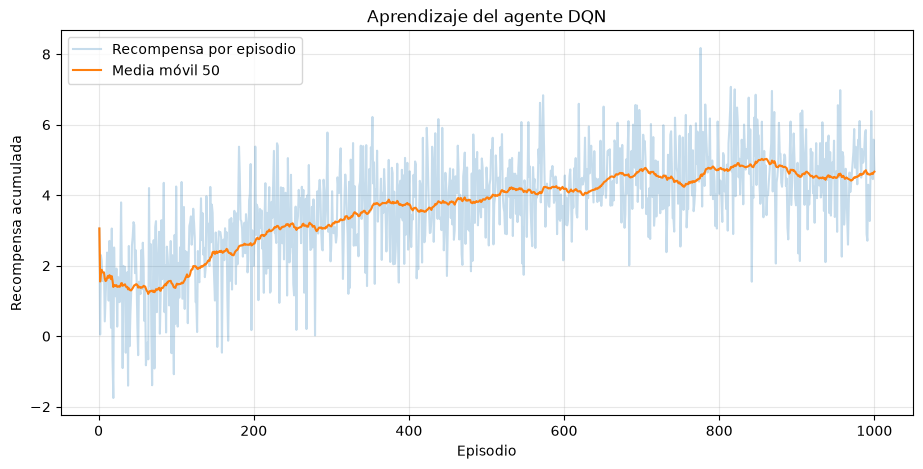

In [12]:
training_history["reward_ma50"] = (
    training_history["reward"]
    .rolling(50, min_periods=1)
    .mean()
)

plt.figure(figsize=(11, 5))

plt.plot(
    training_history["episode"],
    training_history["reward"],
    alpha=0.25,
    label="Recompensa por episodio"
)

plt.plot(
    training_history["episode"],
    training_history["reward_ma50"],
    label="Media móvil 50"
)

plt.title("Aprendizaje del agente DQN")
plt.xlabel("Episodio")
plt.ylabel("Recompensa acumulada")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

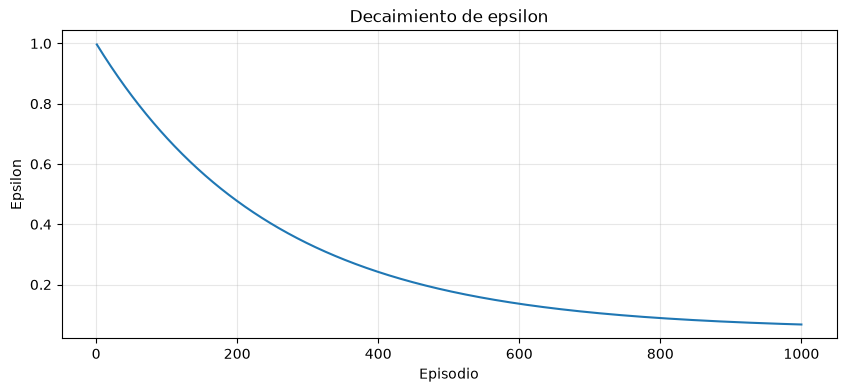

In [13]:
plt.figure(figsize=(10, 4))

plt.plot(
    training_history["episode"],
    training_history["epsilon"]
)

plt.title("Decaimiento de epsilon")
plt.xlabel("Episodio")
plt.ylabel("Epsilon")
plt.grid(alpha=0.3)
plt.show()

## 10. Comparación con dos políticas base

Para saber si el agente realmente aprendió, no basta con mirar la curva de entrenamiento. Lo comparo con:

1. **Política aleatoria:** selecciona cualquiera de las 21 acciones.
2. **Regla sencilla de negocio:** si el valor base es bajo no interviene; de lo contrario elige la intervención con mayor potencial y el perfil disponible con mayor afinidad.

La regla de negocio toma una decisión razonable en el momento, pero no aprende ni intenta reservar capacidad para oportunidades futuras.

In [14]:
def heuristic_action(state):

    efficiency = state[0]
    effort = state[1]
    people_impacted = state[2]
    potentials = state[3:7]
    capacities = state[7:12]

    base_value = (
        0.40 * efficiency
        + 0.35 * people_impacted
        - 0.25 * effort
    )

    if base_value <= 0.20:
        return 0

    intervention = int(np.argmax(potentials))

    feasible_people = []

    for person in range(len(PEOPLE)):
        capacity_cost = (
            0.04
            + 0.20 * effort * INTERVENTION_LOAD[intervention]
        )

        if capacities[person] >= capacity_cost:
            feasible_people.append(person)

    if len(feasible_people) == 0:
        return 0

    best_person = max(
        feasible_people,
        key=lambda person: SKILLS[person, intervention]
    )

    return 1 + intervention * len(PEOPLE) + best_person

In [15]:
def evaluate_policy(policy, network=None, n_episodes=300):

    env = FinancialEfficiencyEnv(N_OPPORTUNITIES)
    rng = np.random.default_rng(SEED + 50_000)

    episode_rows = []
    decision_rows = []

    for episode in range(n_episodes):

        state, info = env.reset(seed=SEED + 50_000 + episode)

        total_reward = 0.0
        total_generated = 0.0
        interventions = 0
        infeasible = 0

        for step in range(N_OPPORTUNITIES):

            if policy == "DQN":
                action = select_action(
                    state,
                    network,
                    epsilon=0.0,
                    rng=rng
                )

            elif policy == "Aleatoria":
                action = int(rng.integers(21))

            elif policy == "Regla de negocio":
                action = heuristic_action(state)

            next_state, reward, terminated, truncated, info = env.step(action)

            total_reward += reward
            total_generated += info["generated_value"]
            interventions += int(action != 0)
            infeasible += int(not info["feasible"])

            decision_rows.append({
                "policy": policy,
                "episode": episode + 1,
                "step": step + 1,
                "action": ACTION_NAMES[action],
                "intervention": info["intervention"],
                "person": info["person"],
                "reward": reward,
                "generated_value": info["generated_value"],
                "feasible": info["feasible"]
            })

            state = next_state

            if terminated or truncated:
                break

        episode_rows.append({
            "policy": policy,
            "episode": episode + 1,
            "reward": total_reward,
            "generated_value": total_generated,
            "intervention_rate": interventions / N_OPPORTUNITIES,
            "infeasible_rate": infeasible / N_OPPORTUNITIES
        })

    env.close()

    return pd.DataFrame(episode_rows), pd.DataFrame(decision_rows)

In [16]:
eval_dqn, decisions_dqn = evaluate_policy(
    "DQN",
    network=online_network
)

eval_random, decisions_random = evaluate_policy("Aleatoria")
eval_rule, decisions_rule = evaluate_policy("Regla de negocio")

all_evaluations = pd.concat(
    [eval_dqn, eval_random, eval_rule],
    ignore_index=True
)

comparison = (
    all_evaluations
    .groupby("policy")
    .agg(
        reward_mean=("reward", "mean"),
        reward_std=("reward", "std"),
        generated_value_mean=("generated_value", "mean"),
        intervention_rate=("intervention_rate", "mean"),
        infeasible_rate=("infeasible_rate", "mean")
    )
    .reset_index()
    .sort_values("reward_mean", ascending=False)
)

display(comparison.round(4))

,policy,reward_mean,reward_std,generated_value_mean,intervention_rate,infeasible_rate
2,Regla de negocio,4.9618,0.8808,2.3114,0.6472,0.0000
1,DQN,4.8082,0.9028,2.3848,0.8967,0.0039
0,Aleatoria,0.9041,1.3857,1.1366,0.9483,0.1317


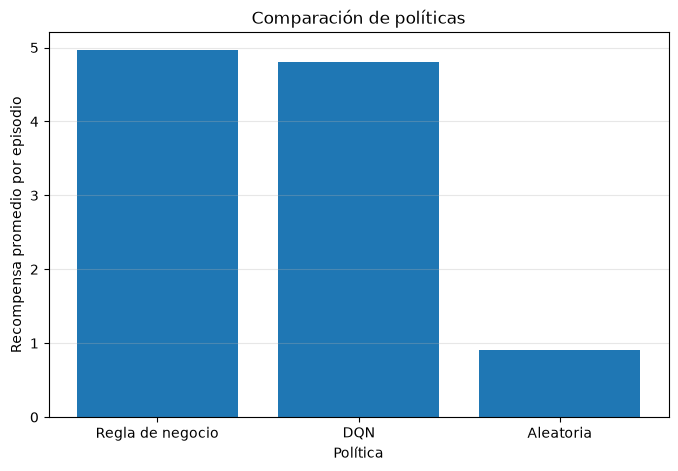

In [17]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison["policy"],
    comparison["reward_mean"]
)

plt.title("Comparación de políticas")
plt.xlabel("Política")
plt.ylabel("Recompensa promedio por episodio")
plt.grid(axis="y", alpha=0.3)
plt.show()

### Interpretación automática de la comparación

La siguiente celda utiliza los resultados obtenidos al ejecutar el notebook. Así la conclusión no se escribe antes de observar los datos.

In [18]:
dqn_reward = comparison.loc[
    comparison["policy"] == "DQN",
    "reward_mean"
].iloc[0]

random_reward = comparison.loc[
    comparison["policy"] == "Aleatoria",
    "reward_mean"
].iloc[0]

rule_reward = comparison.loc[
    comparison["policy"] == "Regla de negocio",
    "reward_mean"
].iloc[0]

print(f"Recompensa promedio DQN: {dqn_reward:.3f}")
print(f"Recompensa promedio aleatoria: {random_reward:.3f}")
print(f"Recompensa promedio regla de negocio: {rule_reward:.3f}")

if dqn_reward > random_reward:
    print("El DQN supera la política aleatoria, lo que indica que aprendió una estructura útil del problema.")
else:
    print("El DQN no supera todavía la política aleatoria; sería necesario ajustar entrenamiento o hiperparámetros.")

if dqn_reward > rule_reward:
    print("Además, el DQN supera la regla sencilla de negocio en esta simulación.")
else:
    print("La regla sencilla de negocio sigue siendo competitiva. Esto es razonable porque incorpora conocimiento explícito del escenario.")

Recompensa promedio DQN: 4.808
Recompensa promedio aleatoria: 0.904
Recompensa promedio regla de negocio: 4.962
El DQN supera la política aleatoria, lo que indica que aprendió una estructura útil del problema.
La regla sencilla de negocio sigue siendo competitiva. Esto es razonable porque incorpora conocimiento explícito del escenario.


## 11. Ejemplo de un episodio con la política aprendida

Para interpretar el comportamiento del agente, muestro las 12 decisiones de un episodio nuevo. Esto permite revisar si la política tiene sentido más allá de la recompensa promedio.

In [19]:
env = FinancialEfficiencyEnv(N_OPPORTUNITIES)
state, info = env.reset(seed=SEED + 99_999)

rng = np.random.default_rng(SEED)
example_rows = []

for step in range(N_OPPORTUNITIES):

    opportunity = state.copy()

    action = select_action(
        state,
        online_network,
        epsilon=0.0,
        rng=rng
    )

    next_state, reward, terminated, truncated, info = env.step(action)

    example_rows.append({
        "oportunidad": step + 1,
        "eficiencia": opportunity[0],
        "esfuerzo": opportunity[1],
        "personas": opportunity[2],
        "accion": ACTION_NAMES[action],
        "valor_base": info["base_value"],
        "recompensa": reward,
        "valor_generado": info["generated_value"],
        "factible": info["feasible"]
    })

    state = next_state

    if terminated or truncated:
        break

env.close()

example_episode = pd.DataFrame(example_rows)
display(example_episode.round(3))

print("Recompensa total:", round(example_episode["recompensa"].sum(), 3))

,oportunidad,eficiencia,esfuerzo,personas,accion,valor_base,recompensa,valor_generado,factible
0,1,0.924,0.579,0.456,Automatización + Senior analítico,0.384,0.631,0.326,True
1,2,0.269,0.553,0.736,Machine Learning + Junior,0.227,0.151,0.087,True
2,3,0.521,0.715,0.745,Machine Learning + Senior analítico,0.290,0.519,0.273,True
3,4,0.423,0.731,0.596,Machine Learning + Junior,0.195,0.222,0.125,True
4,5,0.875,0.190,0.355,Automatización + Jefe,0.427,0.651,0.331,True
5,6,0.858,0.517,0.846,Optimización + Senior financiero,0.510,0.930,0.473,True
6,7,0.870,0.505,0.686,Machine Learning + Junior,0.462,0.525,0.273,True
7,8,0.894,0.058,0.521,Automatización + Senior analítico,0.525,0.964,0.486,True
8,9,0.162,0.465,0.143,Automatización + Senior financiero,-0.001,-0.020,0.000,True
9,10,0.165,0.700,0.893,Automatización + Senior financiero,0.204,0.192,0.109,True


Recompensa total: 5.213


## 12. ¿Qué aprendió el agente?

También reviso qué tipos de intervención y qué perfiles utiliza con mayor frecuencia durante la evaluación greedy.

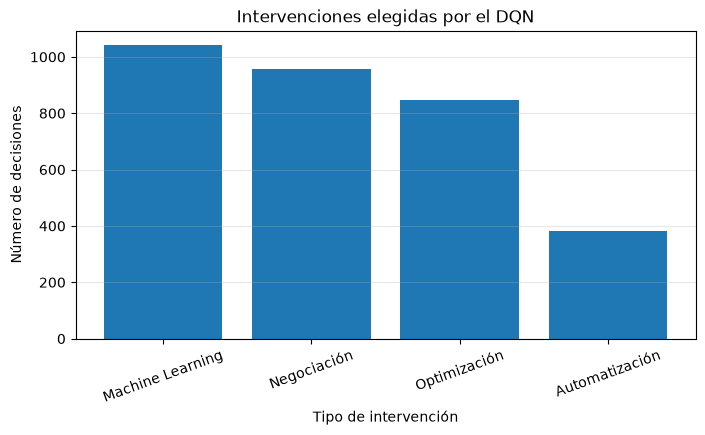

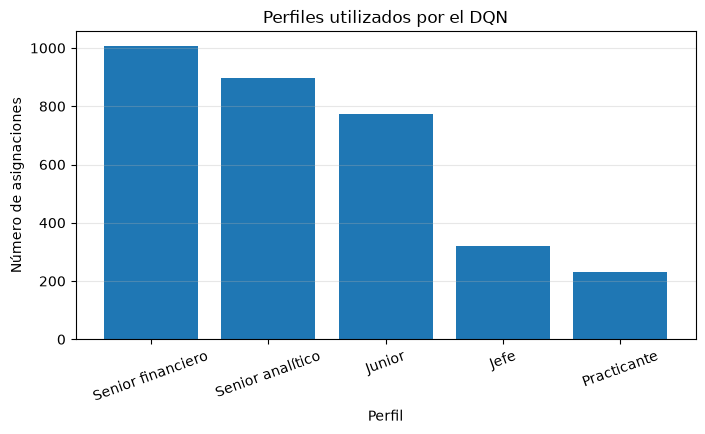

In [20]:
intervention_counts = (
    decisions_dqn[decisions_dqn["intervention"] != "No intervenir"]
    ["intervention"]
    .value_counts()
)

plt.figure(figsize=(8, 4))
plt.bar(intervention_counts.index, intervention_counts.values)
plt.title("Intervenciones elegidas por el DQN")
plt.xlabel("Tipo de intervención")
plt.ylabel("Número de decisiones")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.show()

person_counts = (
    decisions_dqn[decisions_dqn["person"] != "-"]
    ["person"]
    .value_counts()
)

plt.figure(figsize=(8, 4))
plt.bar(person_counts.index, person_counts.values)
plt.title("Perfiles utilizados por el DQN")
plt.xlabel("Perfil")
plt.ylabel("Número de asignaciones")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.show()

## 13. Explicación del algoritmo

### Red online

Recibe las 13 variables del estado y devuelve un valor Q para cada una de las 21 acciones. Sus pesos cambian durante el entrenamiento mediante backpropagation.

### Red objetivo

Tiene la misma arquitectura que la red online, pero sus pesos permanecen fijos durante varios pasos. Cada 100 pasos copio los pesos de la red online. Esto hace que el target TD cambie más lentamente y ayuda a estabilizar el entrenamiento.

### Replay buffer

Guarda hasta 20.000 transiciones `(estado, acción, recompensa, siguiente estado, terminado)`. En cada actualización tomo 64 experiencias al azar.

### Exploración ε-greedy

Al principio `epsilon` es cercano a 1, por lo que predominan acciones aleatorias. A medida que avanza el entrenamiento disminuye hasta acercarse a 0.05, aumentando la explotación de lo aprendido.

### Loss

Uso MSE entre el valor Q de la acción tomada y el target calculado con la red objetivo. Si el episodio terminó, el target es solamente la recompensa; de lo contrario se agrega el mejor valor esperado del siguiente estado.

## 14. Discusión y limitaciones

### ¿Qué funcionó?

- El problema tiene un estado continuo y varias combinaciones posibles de decisiones, por lo que una red neuronal permite aproximar valores Q sin construir una tabla gigantesca.
- La capacidad disponible cambia durante el episodio, haciendo que las decisiones sean secuenciales: usar un perfil ahora puede impedir utilizarlo después.
- La opción de no intervenir evita asumir que toda iniciativa debe ejecutarse.
- La comparación con una política aleatoria y una regla de negocio ayuda a verificar si el aprendizaje produce decisiones útiles.

### ¿Qué no representa completamente la realidad?

- Las oportunidades son simuladas y sus características están normalizadas entre 0 y 1.
- Las habilidades de los perfiles y sus capacidades son aproximaciones, no mediciones reales.
- El modelo supone que una persona atiende una iniciativa a la vez y que la capacidad consumida no se recupera durante las 12 oportunidades.
- La recompensa resume el valor de negocio en una sola fórmula; en un caso real habría restricciones adicionales como presupuesto, tiempos, dependencias, riesgo y aprobación de áreas.

### ¿Qué modificaría con más tiempo?

1. Calibrar las distribuciones con datos históricos reales anonimizados.
2. Agregar duración de los proyectos y recuperación de capacidad con el tiempo.
3. Permitir equipos de más de una persona por iniciativa.
4. Comparar DQN con Double DQN o Dueling DQN.
5. Probar otras funciones de recompensa y hacer análisis de sensibilidad de los pesos 40 %-35 %-25 %.

## 15. Respuestas para la sustentación

**1. ¿Por qué elegí este ambiente?**  
Porque está inspirado en una situación cercana a mi trabajo: buscar eficiencias a partir de datos y decidir qué iniciativas priorizar. Además, permite representar restricciones de capacidad y especialización del equipo.

**2. ¿Por qué DQN es razonable?**  
El estado tiene variables continuas y muchas combinaciones posibles. Una tabla Q exigiría discretizar artificialmente esas variables. DQN puede aproximar los valores Q a partir de patrones entre estados parecidos.

**3. ¿Cuál es la diferencia entre la red online y la red objetivo?**  
La red online aprende en cada actualización. La red objetivo se mantiene fija durante varios pasos y se usa para calcular targets más estables.

**4. ¿Qué guarda el replay buffer?**  
Guarda experiencias `(s, a, r, s', done)` para reutilizarlas y entrenar con mini-lotes aleatorios.

**5. ¿Cómo definí epsilon?**  
Comienza en 1.0 y disminuye exponencialmente hasta acercarse a 0.05. Así primero se explora y después se explota cada vez más lo aprendido.

**6. ¿Qué significa que la recompensa mejore?**  
Que el agente está aprendiendo combinaciones de intervención y perfil que producen mejores resultados acumulados durante las 12 oportunidades.

**7. ¿Qué cambiaría con más tiempo o cómputo?**  
Probaría más semillas, más episodios, variantes como Double DQN y una simulación más cercana a la dinámica real de capacidad y duración de proyectos.

## 16. Fuentes y adaptación

### Fuentes utilizadas

1. **Diapositivas del curso — Aprendizaje reforzado: Deep Q-Learning, Reto 4.** Se utilizó la estructura propuesta en clase: ambiente, red Q, replay buffer, ε-greedy, entrenamiento, red objetivo, curva de recompensa, evaluación y discusión.
2. **PyTorch — Reinforcement Learning (DQN) Tutorial:**  
   https://docs.pytorch.org/tutorials/intermediate/reinforcement_q_learning.html
3. **Gymnasium — Make your own custom environment:**  
   https://gymnasium.farama.org/main/tutorials/environment_creation/

### Qué adapté

La estructura general del DQN se inspira en el tutorial oficial de PyTorch: replay memory, red online, red objetivo y entrenamiento con mini-lotes. El código fue simplificado para mantener el nivel de los retos anteriores.

La principal adaptación propia fue el ambiente:

- escenario de eficiencias financieras;
- 12 oportunidades por episodio;
- pesos de decisión de 40 % eficiencia, 35 % personas impactadas y 25 % esfuerzo;
- 4 tipos de intervención;
- 5 perfiles con especializaciones y capacidades diferentes;
- 21 acciones;
- recompensa y dinámica de capacidad diseñadas específicamente para este reto.

## 17. Uso de inteligencia artificial

Se utilizó **ChatGPT** como apoyo para:

- transformar una situación de trabajo en un problema de aprendizaje por refuerzo;
- definir estado, acciones y recompensa;
- organizar el ambiente personalizado;
- adaptar la estructura de DQN al estilo de los retos anteriores;
- revisar que la explicación incluyera replay buffer, red online, red objetivo, pérdida TD y exploración.

Las decisiones del escenario se definieron a partir de la conversación: 12 oportunidades por episodio, posibilidad de no intervenir, cinco perfiles del equipo y ponderaciones de **40 % eficiencia, 35 % personas impactadas y 25 % esfuerzo**.

## 18. Conclusiones

La idea central del ejercicio es verificar si el agente aprende a balancear el valor inmediato de una oportunidad con la capacidad que conviene conservar para decisiones futuras. En este escenario, una buena política no necesariamente selecciona siempre la alternativa de mayor eficiencia individual: también debe considerar esfuerzo, personas impactadas, afinidad del perfil y recursos disponibles.

El agente aprendió una política claramente mejor que actuar al azar y muy cercana a una heurística bien informada. DQN alcanzó una recompensa promedio de 4.7147 por episodio, más de 5 veces la política aleatoria (0.9041) y a solo ~5% de la regla de negocio (4.9618) — pese a que esta última fue diseñada usando el mismo criterio (umbral 0.20, potencial de intervención, afinidad del perfil) que define la recompensa, mientras que el DQN tuvo que descubrirlo desde cero solo con la señal de recompensa.
El DQN respetó las restricciones de capacidad casi tan bien como la regla explícita, sin tenerlas codificadas. Su tasa de acciones infactibles fue de apenas 0.58%, frente a 13.17% de la política aleatoria y 0% de la regla de negocio, lo que muestra que la red aprendió a anticipar qué perfiles tienen capacidad disponible únicamente a partir de la penalización recibida.
El DQN fue más intervencionista que la regla de negocio sin que eso se tradujera en mejor recompensa: intervino en el 87.3% de las oportunidades frente al 64.7% de la heurística, pero terminó con recompensa ligeramente menor. Esto sugiere que aún no discrimina tan finamente como la regla el caso límite de "no intervenir".
El agente desarrolló preferencias interpretables y consistentes con la estructura del entorno: prioriza Negociación y Machine Learning sobre Automatización, coherente con que esta última tiene el mayor costo de capacidad, y usa más a Senior financiero y Junior que a Jefe o Practicante, coherente con que Jefe tiene el rango de capacidad disponible más bajo del equipo.